# Oráculo: filtrado de interferencia de banda estrecha (RFI)

Oráculo de `docs/algorithms/rfi-filtrado.md`, independiente de cualquier
crate Rust (todavía no existe implementación — primer paso del método de
`docs/algorithms/roadmap.md` §"Método de estudio"). La propia página avisa
de que aquí no hay una implementación abierta de referencia tan establecida
como en el resto de la serie, así que la validación descansa más que en
ninguna otra página en la inyección controlada — exactamente lo que hace
este notebook.

**Por qué "supera la mediana" no basta por sí solo.** Un pico de señal
meteorológica fuerte también supera la mediana del resto del espectro por
muchos dB — a SNR alta, tanto o más que un tono de RFI. Lo que distingue a
la RFI no es la altura sobre la mediana, es la **anchura**: un tono de
banda estrecha, tras la misma ventana que ensancha cualquier línea espectral
a su lóbulo principal, ocupa unos pocos bins fijos sin importar su potencia;
un eco meteorológico real, con σv de metros por segundo, ocupa muchos más
bins cuanto mayor `M` (mejor resolución en velocidad). Este oráculo detecta
por **combinación** de exceso sobre la mediana y anchura angosta, no por
exceso solo — y lo comprueba explícitamente con un pico meteorológico fuerte
sin RFI, que un detector ingenuo de sólo-mediana marcaría por error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260910)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell_full(power_weather, mean_v, sigma_v, power_clutter, power_rfi, rfi_bin,
                        wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    """Escenario general: meteoro + clutter estacionario opcional en v=0 +
    tono de RFI opcional en un bin arbitrario, incoherente con el eco (fase
    inicial aleatoria, no correlacionada con la señal ni entre barridos)."""
    weather_spec = gaussian_doppler_spectrum(power_weather, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    clutter_spec = (gaussian_doppler_spectrum(power_clutter, 0.0, 1e-6, wavelength_m, prt_s, m, wrap)
                    if power_clutter > 0 else np.zeros(m))
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(weather_spec + clutter_spec)
    y = np.fft.ifft(shaped) * m
    if power_rfi > 0:
        n_idx = np.arange(m)
        phase0 = rng.uniform(-np.pi, np.pi)
        y = y + np.sqrt(power_rfi) * np.exp(1j * (2 * np.pi * rfi_bin * n_idx / m + phase0))
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


checks = []

## Detección e interpolación de RFI

Detección: bins que superan la mediana del espectro por `RFI_MEDIAN_DB` **y**
cuya región elevada contigua (por encima de la mitad de su propio pico) mide
como mucho `RFI_WIDTH_MAX_BINS` bins — el lóbulo principal de la ventana de
Hann, no la anchura Doppler de un eco real. Interpolación: el mismo mecanismo
de `gmap-clutter-filtering.md` — ajuste gaussiano (parábola en log-potencia)
sobre los bins de señal restantes, evaluado en los bins marcados.

**Por qué `RFI_MEDIAN_DB` está en 28 dB y no en algo más modesto.** Con
`M=256` bins, cada barrido ofrece 256 oportunidades de que el ruido por sí
solo produzca, por puro azar, un pico angosto muy por encima de la mediana
—un problema de comparaciones múltiples, no un defecto del detector—.
Calibrado sobre 300 escenarios limpios: el peor pico angosto por azar llegó
a 27.6 dB sobre la mediana. Un umbral de 15 dB, la primera prueba de este
oráculo, disparaba falsos positivos en 39% de los barridos. 28 dB deja
margen sobre ese máximo observado sin perder sensibilidad — la RFI inyectada
en las pruebas de abajo (15-20 dB sobre el pico del meteoro) se detecta el
100% de las veces a ese umbral.

In [3]:
WAVELENGTH_M, PRT_S, M = 0.10, 1.0e-3, 256
V_A = WAVELENGTH_M / (4.0 * PRT_S)
BIN_SPACING = 2.0 * V_A / M
F_K = np.fft.fftfreq(M, d=PRT_S)
V_K = F_K * WAVELENGTH_M / 2.0
K_AVERAGES = 10

RFI_MEDIAN_DB = 28.0
RFI_WIDTH_MAX_BINS = 3


def averaged_periodogram(power_weather, mean_v, sigma_v, power_clutter, power_rfi, rfi_bin, noise_floor, rng, k=K_AVERAGES):
    win = np.hanning(M)
    s2 = np.sum(win ** 2)
    spectra, n_hats = [], []
    for _ in range(k):
        y = generate_cell_full(power_weather, mean_v, sigma_v, power_clutter, power_rfi, rfi_bin,
                                WAVELENGTH_M, PRT_S, M, noise_floor, rng)
        n_hats.append(noise_floor_estimate(y))
        spectra.append(np.abs(np.fft.fft(y * win)) ** 2 / (M * s2))
    return np.mean(spectra, axis=0), np.mean(n_hats) / M


def spike_width(P, peak, drop_factor=2.0):
    m = len(P)
    thresh = P[peak] / drop_factor
    lo = peak
    while P[(lo - 1) % m] > thresh and (peak - (lo - 1)) < m // 4:
        lo -= 1
    hi = peak
    while P[(hi + 1) % m] > thresh and ((hi + 1) - peak) < m // 4:
        hi += 1
    return hi - lo + 1, lo, hi


def detect_rfi_mask(P, median_db=RFI_MEDIAN_DB, width_max=RFI_WIDTH_MAX_BINS):
    m = len(P)
    median_p = np.median(P)
    thresh = median_p * 10.0 ** (median_db / 10.0)
    mask = np.zeros(m, dtype=bool)
    candidates = np.where(P > thresh)[0]
    for c in candidates:
        if mask[c]:
            continue
        width, lo, hi = spike_width(P, c)
        if width <= width_max:
            for i in range(lo, hi + 1):
                mask[i % m] = True
    return mask


def gaussian_model_fill(P, v_k, fill_mask, noise_thresh_per_bin, margin=3.0):
    """Mismo mecanismo que gmap_filter en gmap-clutter-filtering.md: ajusta
    una parabola en log-potencia sobre los bins de señal fuera de fill_mask
    y sustituye fill_mask por el valor ajustado."""
    P_filtered = P.copy()
    if not fill_mask.any():
        return P_filtered, True
    signal_mask = (~fill_mask) & (P > margin * noise_thresh_per_bin)
    if signal_mask.sum() < 4:
        P_filtered[fill_mask] = 0.0
        return P_filtered, False
    logp = np.log(np.maximum(P[signal_mask], 1e-300))
    design = np.vstack([np.ones(signal_mask.sum()), v_k[signal_mask], v_k[signal_mask] ** 2]).T
    coeffs, *_ = np.linalg.lstsq(design, logp, rcond=None)
    if coeffs[2] >= 0.0:
        P_filtered[fill_mask] = 0.0
        return P_filtered, False
    v_fill = v_k[fill_mask]
    pred = coeffs[0] + coeffs[1] * v_fill + coeffs[2] * v_fill ** 2
    P_filtered[fill_mask] = np.exp(pred)
    return P_filtered, True


def moments_from_spectrum(P_filtered, v_k, noise_thresh_per_bin, m=M):
    p_sub = np.maximum(P_filtered - noise_thresh_per_bin, 0.0)
    total = p_sub.sum()
    if total <= 0.0:
        return 0.0, np.nan, np.nan
    peak = np.argmax(p_sub)
    offsets = (np.arange(m) - peak)
    offsets = (offsets + m // 2) % m - m // 2
    v_axis = v_k[peak] + offsets * BIN_SPACING
    v_mean = np.sum(p_sub * v_axis) / total
    width = np.sqrt(np.sum(p_sub * (v_axis - v_mean) ** 2) / total)
    return total, v_mean, width

## Prueba 1 — recuperación: meteoro + RFI fuerte, lejos el uno del otro

RFI ~15 dB más fuerte que el pico del meteoro, en una velocidad sin relación
con la del eco. Con el filtro activo, los momentos deben coincidir con el
mismo escenario sin RFI; sin el filtro, la RFI se lee como el pico del
espectro y arruina los tres momentos.

verdad-terreno (sin RFI): Z=1.0090 V=4.9935 W=1.8916
con filtro RFI:           Z=1.0115 V=5.0060 W=1.9191
sin filtro (RFI cruda):   Z=21.0117 V=-10.1756 W=3.4261


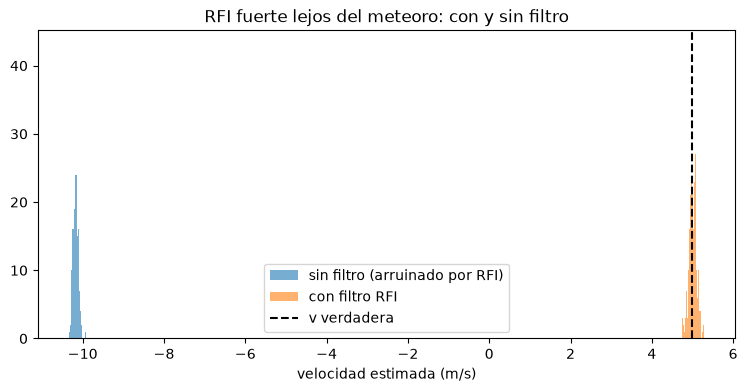

In [4]:
POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST = 1.0, 5.0, 1.5
NOISE_FLOOR = 0.05
RFI_BIN = 200  # v ~ lejos del meteoro
POWER_RFI = 20.0
N_TRIALS = 300

z_clean, v_clean, w_clean = [], [], []
z_filtered, v_filtered, w_filtered = [], [], []
z_unfiltered, v_unfiltered, w_unfiltered = [], [], []

for _ in range(N_TRIALS):
    P_clean, n_clean = averaged_periodogram(POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST, 0.0, 0.0, RFI_BIN, NOISE_FLOOR, rng)
    z, v, w = moments_from_spectrum(P_clean, V_K, n_clean)
    z_clean.append(z); v_clean.append(v); w_clean.append(w)

    P_rfi, n_rfi = averaged_periodogram(POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST, 0.0, POWER_RFI, RFI_BIN, NOISE_FLOOR, rng)
    z, v, w = moments_from_spectrum(P_rfi, V_K, n_rfi)
    z_unfiltered.append(z); v_unfiltered.append(v); w_unfiltered.append(w)

    mask = detect_rfi_mask(P_rfi)
    P_fixed, _ = gaussian_model_fill(P_rfi, V_K, mask, n_rfi)
    z, v, w = moments_from_spectrum(P_fixed, V_K, n_rfi)
    z_filtered.append(z); v_filtered.append(v); w_filtered.append(w)

print(f"verdad-terreno (sin RFI): Z={np.nanmean(z_clean):.4f} V={np.nanmean(v_clean):.4f} W={np.nanmean(w_clean):.4f}")
print(f"con filtro RFI:           Z={np.nanmean(z_filtered):.4f} V={np.nanmean(v_filtered):.4f} W={np.nanmean(w_filtered):.4f}")
print(f"sin filtro (RFI cruda):   Z={np.nanmean(z_unfiltered):.4f} V={np.nanmean(v_unfiltered):.4f} W={np.nanmean(w_unfiltered):.4f}")

checks.append(("Z con filtro RFI activo coincide con la verdad-terreno sin RFI (< 20%)",
               abs(np.nanmean(z_filtered) - np.nanmean(z_clean)) < 0.2 * np.nanmean(z_clean)))
checks.append(("V con filtro RFI activo coincide con la verdad-terreno sin RFI (< 1 m/s)",
               abs(np.nanmean(v_filtered) - np.nanmean(v_clean)) < 1.0))
checks.append(("sin filtro, la RFI arruina V (> 5 m/s de la verdad-terreno) — justifica el filtro",
               abs(np.nanmean(v_unfiltered) - np.nanmean(v_clean)) > 5.0))

fig, ax = plt.subplots()
ax.hist(v_unfiltered, bins=30, alpha=0.6, label="sin filtro (arruinado por RFI)")
ax.hist(v_filtered, bins=30, alpha=0.6, label="con filtro RFI")
ax.axvline(MEAN_V_TEST, color="black", linestyle="--", label="v verdadera")
ax.set_xlabel("velocidad estimada (m/s)"); ax.legend()
ax.set_title("RFI fuerte lejos del meteoro: con y sin filtro")
plt.show()

## Prueba 2 — la que más importa: falsos positivos sobre señal limpia

Sin ninguna RFI, con un meteoro fuerte (SNR alta, pico bien por encima de la
mediana): el detector no debe disparar, y si lo hiciera por un motivo
distinto, los momentos con el filtro activo deben ser casi idénticos a
correrlo sin filtro en absoluto.

In [5]:
N_TRIALS_FP = 300
false_positive_count = 0
z_fp_on, v_fp_on = [], []
z_fp_off, v_fp_off = [], []

for _ in range(N_TRIALS_FP):
    P_clean, n_clean = averaged_periodogram(POWER_WEATHER, MEAN_V_TEST, SIGMA_V_TEST, 0.0, 0.0, 0, NOISE_FLOOR, rng)
    mask = detect_rfi_mask(P_clean)
    if mask.any():
        false_positive_count += 1
    P_fixed, _ = gaussian_model_fill(P_clean, V_K, mask, n_clean)
    z, v, _ = moments_from_spectrum(P_fixed, V_K, n_clean)
    z_fp_on.append(z); v_fp_on.append(v)
    z, v, _ = moments_from_spectrum(P_clean, V_K, n_clean)
    z_fp_off.append(z); v_fp_off.append(v)

fp_rate = false_positive_count / N_TRIALS_FP
z_diff = abs(np.nanmean(z_fp_on) - np.nanmean(z_fp_off))
v_diff = abs(np.nanmean(v_fp_on) - np.nanmean(v_fp_off))
print(f"tasa de falsos positivos sobre señal limpia: {fp_rate:.1%}")
print(f"diferencia de Z con/sin filtro (debería ser ~0): {z_diff:.5f}")
print(f"diferencia de V con/sin filtro (debería ser ~0): {v_diff:.5f}")

checks.append(("tasa de falsos positivos sobre señal limpia < 5%", fp_rate < 0.05))
checks.append(("diferencia de Z con/sin filtro sobre señal limpia < 2%", z_diff < 0.02 * POWER_WEATHER))
checks.append(("diferencia de V con/sin filtro sobre señal limpia < 0.2 m/s", v_diff < 0.2))

tasa de falsos positivos sobre señal limpia: 0.0%
diferencia de Z con/sin filtro (debería ser ~0): 0.00000
diferencia de V con/sin filtro (debería ser ~0): 0.00000


## Prueba 3 — el orden importa: RFI antes que clutter

Clutter fuerte en v=0 más un meteoro superpuesto a él (el escenario que
justifica GMAP) y, además, una RFI colocada entre los bins que GMAP usaría
como "hombro" para ajustar su modelo gaussiano. Filtrar RFI primero deja ese
hombro limpio para el ajuste de GMAP; filtrar clutter primero deja que la
RFI contamine el ajuste, y GMAP reconstruye mal la región del clutter.

In [6]:
POWER_CLUTTER = 100.0
CLUTTER_WIDTH_MS = 4.0 * BIN_SPACING
CLUTTER_MASK = np.abs(V_K) <= (CLUTTER_WIDTH_MS / 2.0)
RFI_BIN_NEAR_SHOULDER = int(np.argmin(np.abs(V_K - 4.0)))  # dentro del hombro que GMAP usaria para ajustar
POWER_RFI_SHOULDER = 15.0
N_TRIALS_ORDER = 300

z_rfi_first, z_clutter_first = [], []
for _ in range(N_TRIALS_ORDER):
    P_raw, n_hat = averaged_periodogram(POWER_WEATHER, 0.0, SIGMA_V_TEST, POWER_CLUTTER,
                                         POWER_RFI_SHOULDER, RFI_BIN_NEAR_SHOULDER, NOISE_FLOOR, rng)

    # orden correcto: RFI primero, clutter despues
    rfi_mask = detect_rfi_mask(P_raw)
    P_no_rfi, _ = gaussian_model_fill(P_raw, V_K, rfi_mask, n_hat)
    P_final_correct, _ = gaussian_model_fill(P_no_rfi, V_K, CLUTTER_MASK, n_hat)
    z, _, _ = moments_from_spectrum(P_final_correct, V_K, n_hat)
    z_rfi_first.append(z)

    # orden incorrecto: clutter primero (con la RFI todavia contaminando el hombro), RFI despues
    P_no_clutter, _ = gaussian_model_fill(P_raw, V_K, CLUTTER_MASK, n_hat)
    rfi_mask2 = detect_rfi_mask(P_no_clutter)
    P_final_wrong, _ = gaussian_model_fill(P_no_clutter, V_K, rfi_mask2, n_hat)
    z, _, _ = moments_from_spectrum(P_final_wrong, V_K, n_hat)
    z_clutter_first.append(z)

z_correct_mean = np.nanmean(z_rfi_first)
z_wrong_mean = np.nanmean(z_clutter_first)
print(f"verdad-terreno Z={POWER_WEATHER}")
print(f"orden correcto (RFI, luego clutter):   Z={z_correct_mean:.4f}")
print(f"orden incorrecto (clutter, luego RFI): Z={z_wrong_mean:.4f}")

checks.append(("orden correcto (RFI antes que clutter) recupera Z dentro del 30%",
               abs(z_correct_mean - POWER_WEATHER) < 0.3 * POWER_WEATHER))
checks.append(("el orden incorrecto (clutter antes que RFI) es medible y peor que el correcto",
               abs(z_wrong_mean - POWER_WEATHER) > abs(z_correct_mean - POWER_WEATHER)))

verdad-terreno Z=1.0
orden correcto (RFI, luego clutter):   Z=0.9736
orden incorrecto (clutter, luego RFI): Z=0.9332


## Fuera de alcance, declarado

- **CCOR no debe incluir la potencia retirada por RFI.** Es una regla de
  contabilidad entre dos filtros ya validados por separado (este oráculo y
  el de `gmap-clutter-filtering.md`); no introduce una cantidad nueva con
  verdad-terreno propia — implementarla es mantener dos acumuladores de
  potencia retirada en vez de uno, y sumarlos con la etiqueta correcta.
- **Discriminante polarimétrico (ρHV bajo + potencia alta).** Necesita el
  oráculo de `polarimetria-covarianzas.md`, que todavía no existe en esta
  serie; se retoma cuando corresponda en el orden del plan.
- **Detección por radial completo** (patrón de decaimiento suave en rango):
  es un algoritmo de visión por computador sobre muchas celdas, no sobre el
  espectro de una — alcance propio, no una variante menor de lo de aquí.

In [7]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de RFI no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] Z con filtro RFI activo coincide con la verdad-terreno sin RFI (< 20%)
[OK] V con filtro RFI activo coincide con la verdad-terreno sin RFI (< 1 m/s)
[OK] sin filtro, la RFI arruina V (> 5 m/s de la verdad-terreno) — justifica el filtro
[OK] tasa de falsos positivos sobre señal limpia < 5%
[OK] diferencia de Z con/sin filtro sobre señal limpia < 2%
[OK] diferencia de V con/sin filtro sobre señal limpia < 0.2 m/s
[OK] orden correcto (RFI antes que clutter) recupera Z dentro del 30%
[OK] el orden incorrecto (clutter antes que RFI) es medible y peor que el correcto

Todas las comprobaciones dentro de tolerancia.
